Loading 'lego_pile.png' and 'brick_template.png'...
Running template matching...
Filtering and merging overlapping detections...
Success! Detected 1 target bricks.


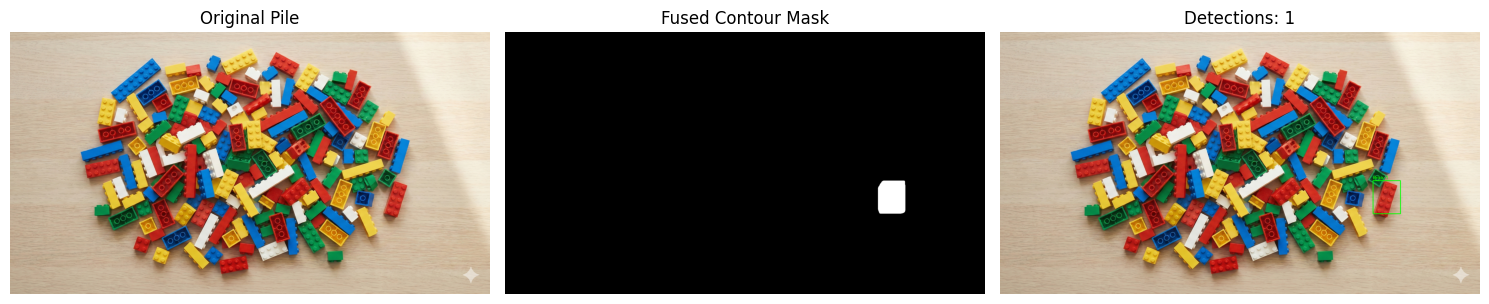

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import argparse

def detect_lego_advanced(pile_image_path, template_image_path, threshold=0.75, save_output=False):
    """
    Detects a template LEGO brick within a larger pile image.

    Args:
        pile_image_path (str): Path to the main image containing scattered bricks.
        template_image_path (str): Path to the cropped template image of the target brick.
        threshold (float): Match confidence threshold (0.0 to 1.0).
        save_output (bool): If True, saves the plotted figure as 'output_result.png'.
    """

    # ---------------------------------------------------------
    # 1. SAFETY CHECKS & LOADING
    # ---------------------------------------------------------
    if not os.path.exists(pile_image_path):
        print(f"ERROR: Cannot find pile image at '{pile_image_path}'.")
        return
    if not os.path.exists(template_image_path):
        print(f"ERROR: Cannot find template image at '{template_image_path}'.")
        return

    print(f"Loading '{pile_image_path}' and '{template_image_path}'...")

    # Load images
    img_bgr = cv2.imread(pile_image_path)
    template = cv2.imread(template_image_path, cv2.IMREAD_GRAYSCALE)

    # Convert main image to RGB (for Matplotlib display) and Grayscale (for processing)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Get template dimensions
    w, h = template.shape[::-1]

    # ---------------------------------------------------------
    # 2. TEMPLATE MATCHING
    # ---------------------------------------------------------
    print("Running template matching...")
    # TM_CCOEFF_NORMED is robust against minor lighting differences
    res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)

    # Filter matches based on the confidence threshold
    loc = np.where(res >= threshold)

    # ---------------------------------------------------------
    # 3. ADVANCED CONTOUR FILTERING (Morphological Merging)
    # ---------------------------------------------------------
    print("Filtering and merging overlapping detections...")
    # Create a blank mask the exact size of our main image
    mask = np.zeros_like(img_gray)

    # Draw a small dot at the center of every valid match
    for pt in zip(*loc[::-1]):
        center_x = pt[0] + (w // 2)
        center_y = pt[1] + (h // 2)
        cv2.circle(mask, (center_x, center_y), radius=5, color=255, thickness=-1)

    # Dilation: Expand the dots until nearby dots fuse into solid shapes.
    # This resolves the issue of multiple bounding boxes appearing on a single brick.
    kernel = np.ones((max(w, h)//2, max(w, h)//2), np.uint8)
    mask_dilated = cv2.dilate(mask, kernel, iterations=1)

    # Find the outlines (contours) of the fused white blobs
    contours, _ = cv2.findContours(mask_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # ---------------------------------------------------------
    # 4. DRAWING THE RESULTS
    # ---------------------------------------------------------
    lego_count = 0
    img_result = img_rgb.copy()

    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Filter out tiny noise (ensure the blob is roughly 20% the size of the template)
        if area > (w * h * 0.2):
            lego_count += 1
            # Get clean bounding box coordinates
            x, y, box_w, box_h = cv2.boundingRect(cnt)

            # Draw a thick green rectangle and label
            cv2.rectangle(img_result, (x, y), (x + box_w, y + box_h), (0, 255, 0), 4)
            cv2.putText(img_result, f'Brick {lego_count}', (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    print(f"Success! Detected {lego_count} target bricks.")

    # ---------------------------------------------------------
    # 5. MATPLOTLIB DISPLAY
    # ---------------------------------------------------------
    plt.figure(figsize=(15, 5))

    # Plot 1: Original Image
    plt.subplot(1, 3, 1)
    plt.title("Original Pile")
    plt.imshow(img_rgb)
    plt.axis('off')

    # Plot 2: Internal Mask
    plt.subplot(1, 3, 2)
    plt.title("Fused Contour Mask")
    plt.imshow(mask_dilated, cmap='gray')
    plt.axis('off')

    # Plot 3: Final Detections
    plt.subplot(1, 3, 3)
    plt.title(f"Detections: {lego_count}")
    plt.imshow(img_result)
    plt.axis('off')

    plt.tight_layout()

    if save_output:
        plt.savefig('output_result.png')
        print("Result saved as 'output_result.png'.")

    plt.show()

if __name__ == "__main__":
    # Set up command line argument parsing
    parser = argparse.ArgumentParser(description="Detect specific LEGO bricks in an image.")
    parser.add_argument('-p', '--pile', type=str, default='lego_pile.png', help="Path to the main image of scattered bricks.")
    parser.add_argument('-t', '--template', type=str, default='brick_template.png', help="Path to the cropped template image.")
    parser.add_argument('--thresh', type=float, default=0.75, help="Match threshold from 0.0 to 1.0 (default: 0.75).")
    parser.add_argument('--save', action='store_true', help="Flag to save the output plot as an image.")

    # This grabs our defined arguments and safely ignores Colab's hidden '-f' argument
    args, unknown = parser.parse_known_args()

    detect_lego_advanced(
        pile_image_path=args.pile,
        template_image_path=args.template,
        threshold=args.thresh,
        save_output=args.save
    )

Isolating red pixels...
Success! Detected 24 red bricks.


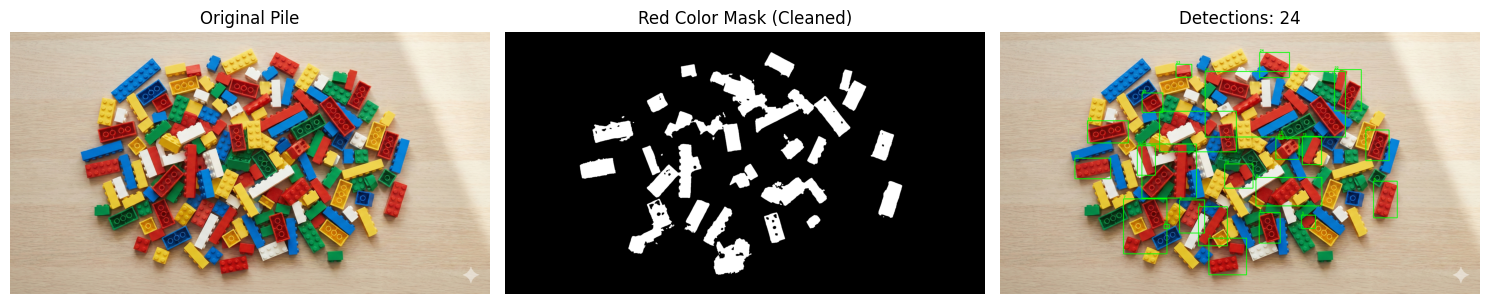

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def detect_all_red_legos(pile_image_path='lego_pile.png'):

    # ---------------------------------------------------------
    # 1. SAFETY CHECKS & LOADING
    # ---------------------------------------------------------
    if not os.path.exists(pile_image_path):
        print(f"ERROR: Cannot find '{pile_image_path}'. Please upload it.")
        return

    # Load image
    img_bgr = cv2.imread(pile_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Convert to HSV (Hue, Saturation, Value) color space
    # HSV is much better for color detection than RGB because it isolates color (Hue) from lighting (Value)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # ---------------------------------------------------------
    # 2. COLOR THRESHOLDING (Finding the Red)
    # ---------------------------------------------------------
    print("Isolating red pixels...")

    # In OpenCV, Hue goes from 0 to 179. Red is tricky because it wraps around the 0 mark.
    # We have to look for red in the lower range (0-10) AND the upper range (160-179).

    # Lower Red Range
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)

    # Upper Red Range
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([179, 255, 255])
    mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

    # Combine both masks to get ALL the red
    red_mask = mask1 + mask2

    # ---------------------------------------------------------
    # 3. CLEANING THE MASK
    # ---------------------------------------------------------
    # Use morphological operations to clean up tiny specks of noise (like a single red pixel on the wood)
    # and fill in small gaps inside the bricks.
    kernel = np.ones((5, 5), np.uint8)
    red_mask_clean = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel) # Removes outside noise
    red_mask_clean = cv2.morphologyEx(red_mask_clean, cv2.MORPH_CLOSE, kernel) # Fills inside holes

    # ---------------------------------------------------------
    # 4. CONTOUR FILTERING & DRAWING
    # ---------------------------------------------------------
    contours, _ = cv2.findContours(red_mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lego_count = 0
    img_result = img_rgb.copy()

    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Filter out tiny noise (only keep shapes larger than 200 pixels)
        if area > 200:
            lego_count += 1
            x, y, w, h = cv2.boundingRect(cnt)

            # Draw a thick green rectangle
            cv2.rectangle(img_result, (x, y), (x + w, y + h), (0, 255, 0), 4)
            # Add a small text label
            cv2.putText(img_result, f'{lego_count}', (x, y - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    print(f"Success! Detected {lego_count} red bricks.")

    # ---------------------------------------------------------
    # 5. MATPLOTLIB DISPLAY
    # ---------------------------------------------------------
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Pile")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Red Color Mask (Cleaned)")
    plt.imshow(red_mask_clean, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"Detections: {lego_count}")
    plt.imshow(img_result)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Ensure you are passing the correct name of your uploaded pile image
    detect_all_red_legos('lego_pile.png')